<a href="https://colab.research.google.com/github/AhmadKevin000/PCVK_Ganjil2026/blob/main/week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

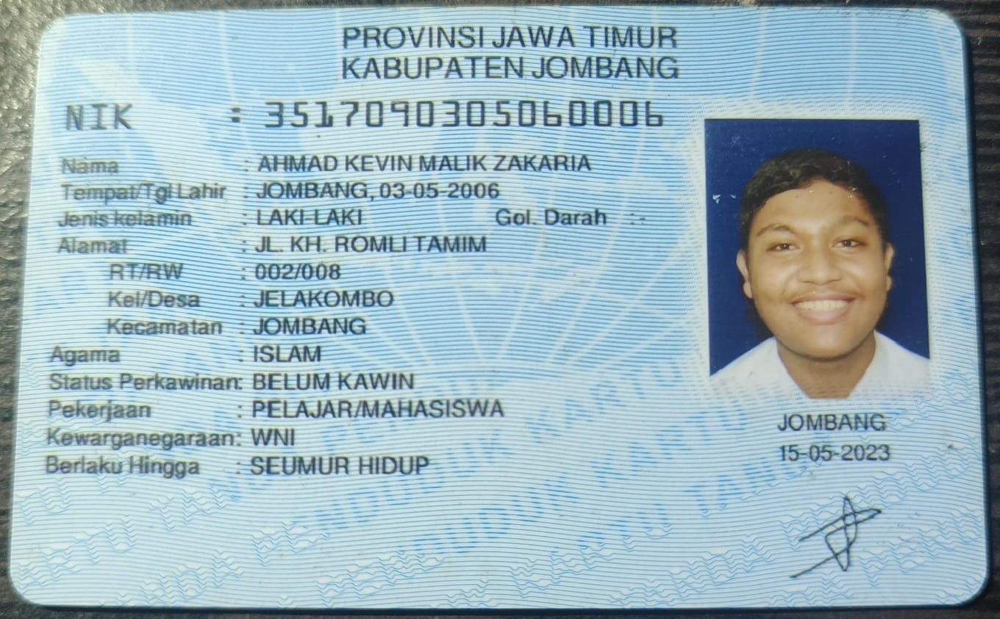

Resolusi gambar:  1360 x 843


In [6]:
img = cv.imread('/content/drive/MyDrive/Matkul Sem 5/PCVK/KTP.jpeg')
cv2_imshow(img)
print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

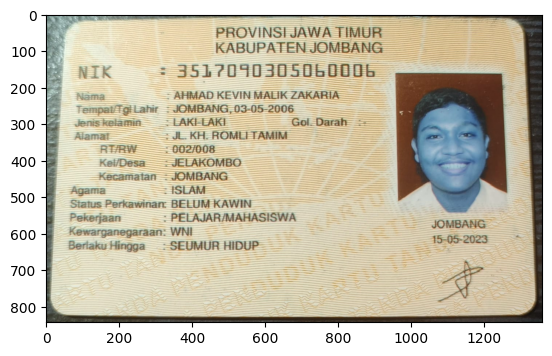

In [7]:
plt.imshow(img)

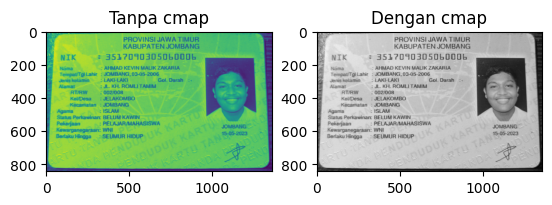

In [8]:
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

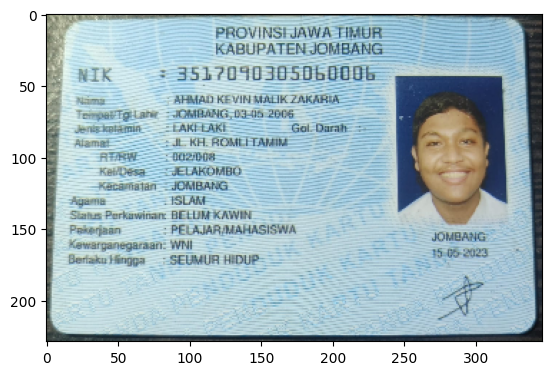

In [9]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

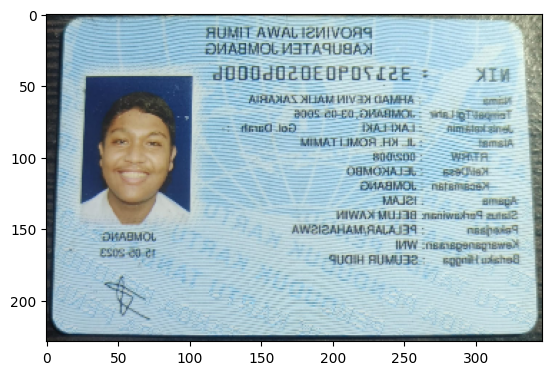

In [10]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

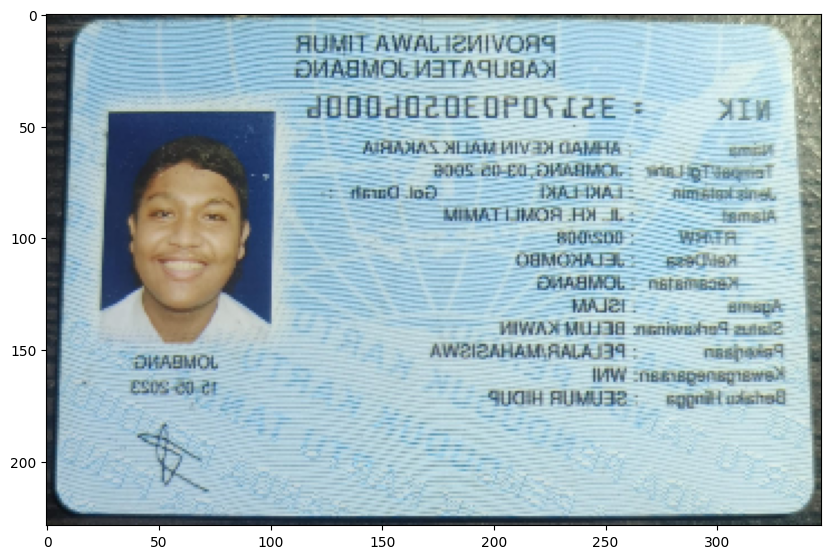

In [11]:
imgFlip=cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

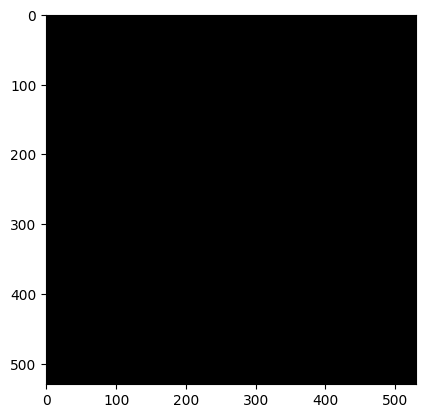

In [12]:
# Membuat black image dengan tipe data int16
black_img = np.zeros(shape=(530,530,3), dtype=np.int16)
plt.imshow(black_img)

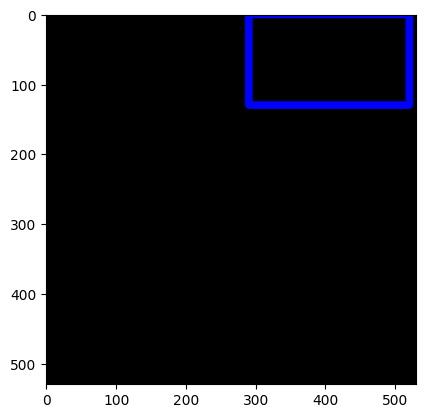

In [13]:
# perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0,0,255), thickness=10)
plt.imshow(black_img)

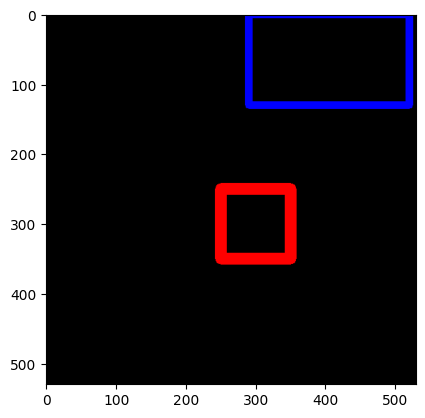

In [14]:
cv.rectangle(black_img,pt1=(250,250), pt2=(350,350),color=(255,0,0), thickness=15)
plt.imshow(black_img)

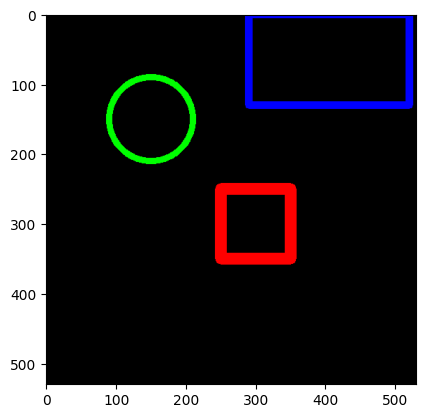

In [15]:
cv.circle(black_img,center=(150,150), radius=60,color=(0,255,0), thickness=8)
plt.imshow(black_img)

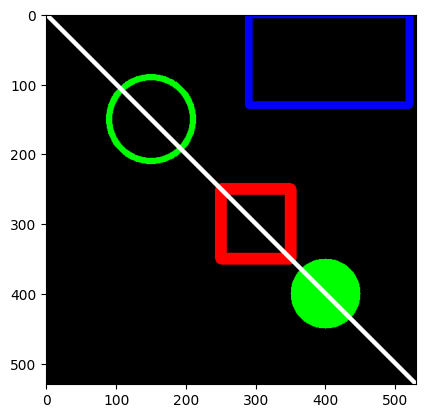

In [16]:
cv.circle(black_img,center=(400,400), radius=50,color=(0,255,0), thickness=-1)
cv.line(black_img,pt1=(0,0), pt2=(530,530),color=(255,255,255), thickness=5)
plt.imshow(black_img)

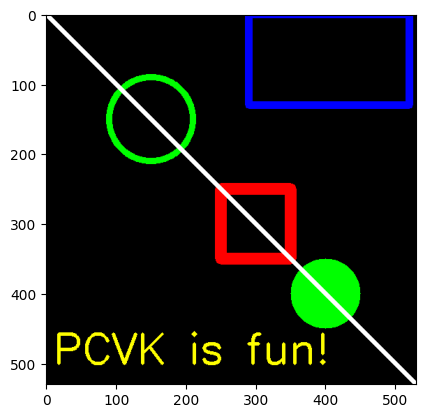

In [17]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

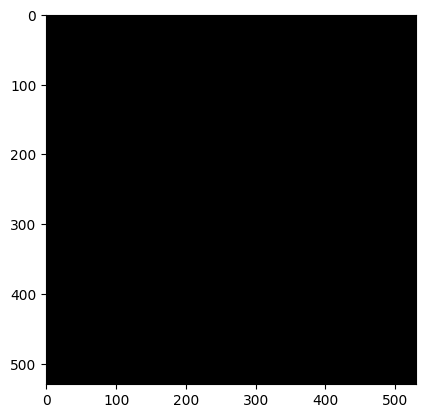

In [18]:
black_img2 = np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

In [19]:
vertices = np.array([[150,350], [250,250], [450,350], [250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [20]:
# nilai 2 untuk menunjukkan bahwa tiap titik dibuat 2 nilai kordinat (x dan y)
pts = vertices.reshape((-1,1,2))
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

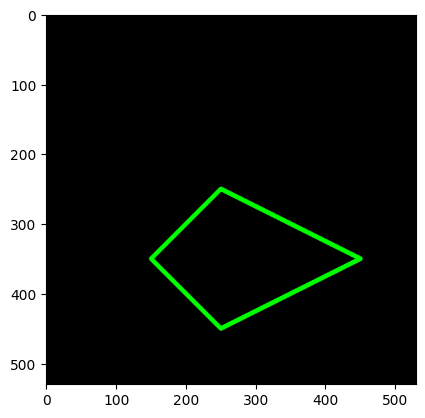

In [21]:
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

=== Tampilan cv2_imshow (Asumsi BGR) ===


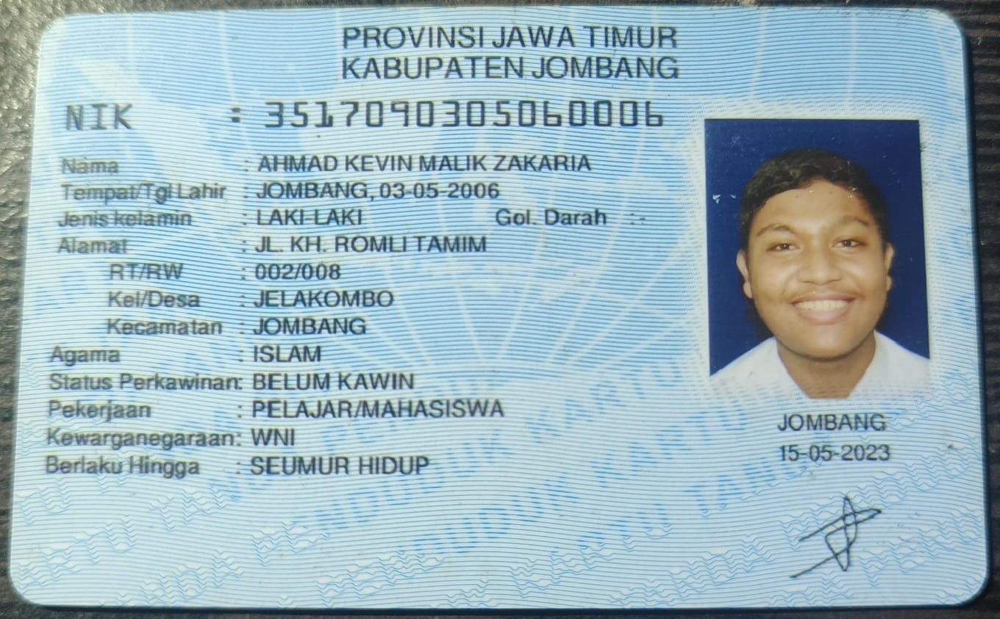

=== Tampilan plt.imshow (Asumsi RGB) ===


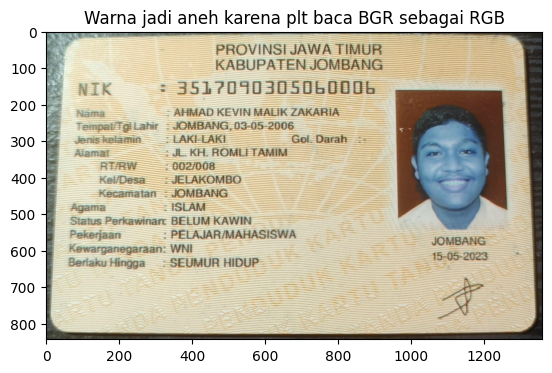

Nilai piksel pojok kiri atas: [183 210 206]


In [22]:
img_bgr = img
print("=== Tampilan cv2_imshow (Asumsi BGR) ===")
cv2_imshow(img_bgr)

print("=== Tampilan plt.imshow (Asumsi RGB) ===")
plt.imshow(img_bgr)
plt.title("Warna jadi aneh karena plt baca BGR sebagai RGB")
plt.show()

print("Nilai piksel pojok kiri atas:", img_bgr[0,0])

In [23]:
# Bikin kanvas hitam 100x100
img_int16 = np.zeros((100,100,3), dtype=np.int16)
img_int32 = np.zeros((100,100,3), dtype=np.int32)

print("--- Kanvas int16 ---")
print("dtype:", img_int16.dtype)
print("min/max:", img_int16.min(), "/", img_int16.max())
print("Memori (bytes):", img_int16.nbytes)

print("\n--- Kanvas int32 ---")
print("dtype:", img_int32.dtype)
print("min/max:", img_int32.min(), "/", img_int32.max())
print("Memori (bytes):", img_int32.nbytes)

--- Kanvas int16 ---
dtype: int16
min/max: 0 / 0
Memori (bytes): 60000

--- Kanvas int32 ---
dtype: int32
min/max: 0 / 0
Memori (bytes): 120000


Nilai piksel [0,0] skimage: [183 210 206]
Nilai piksel [0,0] cv2 konversi: [206 210 183]


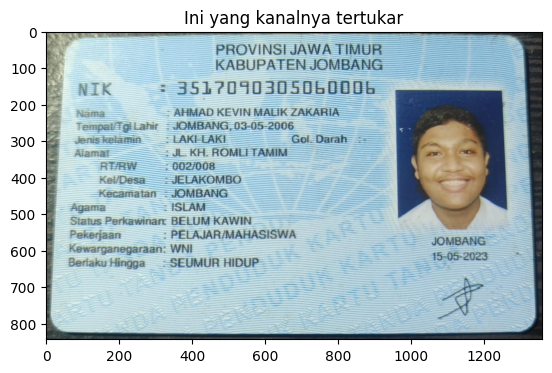

In [24]:
img_skimage = img
img_cv_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

print("Nilai piksel [0,0] skimage:", img_skimage[0,0])
print("Nilai piksel [0,0] cv2 konversi:", img_cv_rgb[0,0])

img_skimage_salah = cv.cvtColor(img_skimage, cv.COLOR_BGR2RGB)
plt.imshow(img_skimage_salah)
plt.title("Ini yang kanalnya tertukar")
plt.show()

Shape SEBELUM figsize besar: (843, 1360, 3)


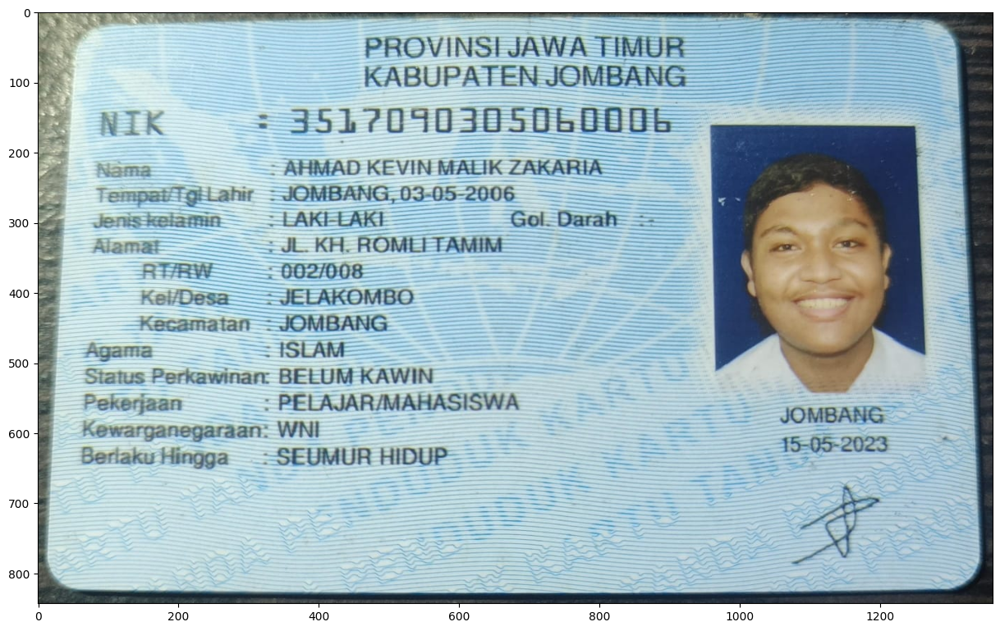

Shape SESUDAH figsize besar: (843, 1360, 3)


In [25]:
print("Shape SEBELUM figsize besar:", img_bgr.shape)

fig = plt.figure(figsize=(15,15))
plt.imshow(img_cv_rgb)
plt.show()

print("Shape SESUDAH figsize besar:", img_bgr.shape)

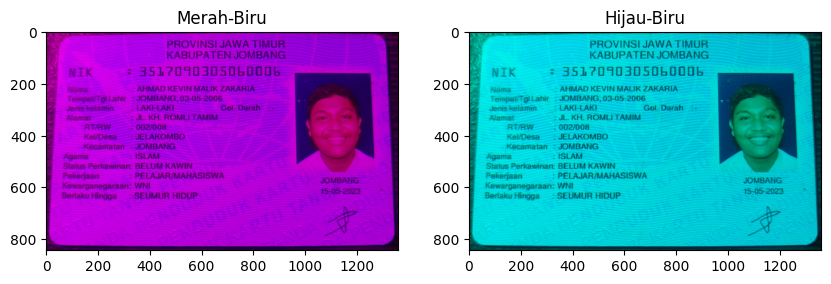

In [28]:
img_asli = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_rb = img_asli.copy()
img_rb[:, :, 1] = 0

img_gb = img_asli.copy()
img_gb[:, :, 0] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rb)
ax[0].set_title('Merah-Biru')
ax[1].imshow(img_gb)
ax[1].set_title('Hijau-Biru')
plt.show()

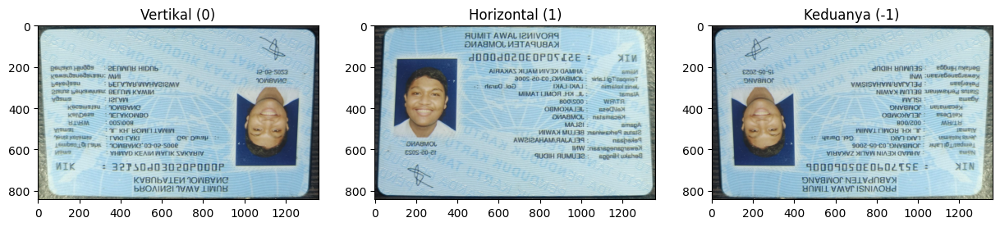

In [29]:
flip_v = cv.flip(img_asli, 0)
flip_h = cv.flip(img_asli, 1)
flip_vh = cv.flip(img_asli, -1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(flip_v)
ax[0].set_title('Vertikal (0)')
ax[1].imshow(flip_h)
ax[1].set_title('Horizontal (1)')
ax[2].imshow(flip_vh)
ax[2].set_title('Keduanya (-1)')
plt.show()

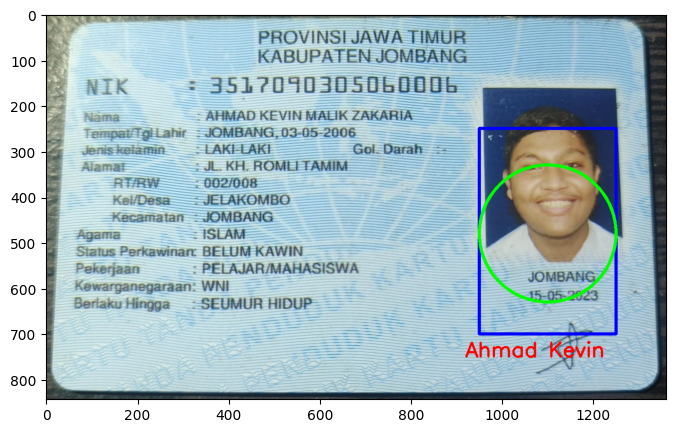

In [34]:
foto_sendiri = img.copy()
foto_rgb = cv.cvtColor(foto_sendiri, cv.COLOR_BGR2RGB)

cv.rectangle(foto_rgb, (950, 250), (1250, 700), (0, 0, 255), 5)

cv.circle(foto_rgb, (1100, 480), 150, (0, 255, 0), 5)

cv.putText(foto_rgb, 'Ahmad Kevin', (920, 750), cv.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 4)

plt.figure(figsize=(8,8))
plt.imshow(foto_rgb)
plt.show()

In [36]:
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

h, w = img_gray.shape
total_pixel = h * w

pixel_terang = np.sum(img_gray > 127)

persentase = (pixel_terang / total_pixel) * 100

print(f"Total piksel: {total_pixel}")
print(f"Piksel terang (>127): {pixel_terang}")
print(f"Persentase piksel terang: {persentase:.2f}%")

Total piksel: 1146480
Piksel terang (>127): 959926
Persentase piksel terang: 83.73%


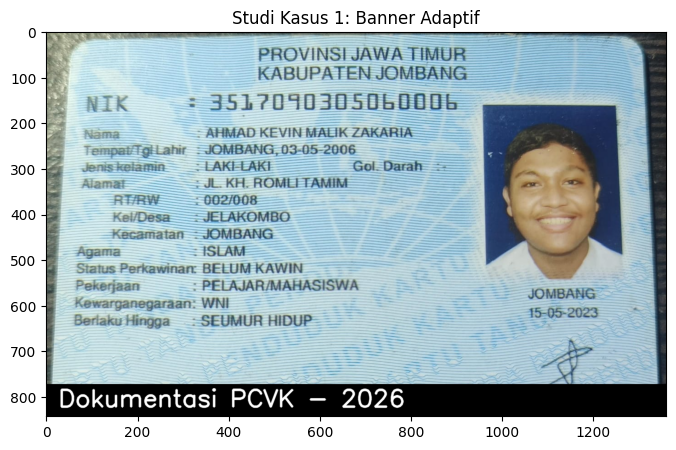

In [38]:
img_kasus1 = cv.cvtColor(img, cv.COLOR_BGR2RGB)

h, w = img_kasus1.shape[:2]

bar_h = h // 12

cv.rectangle(img_kasus1, (0, h - bar_h), (w, h), (0, 0, 0), cv.FILLED)

font_scale = bar_h / 40
thickness = max(1, int(font_scale * 2))

cv.putText(img_kasus1, 'Dokumentasi PCVK - 2026', (int(w * 0.02), h - int(bar_h * 0.3)),
           cv.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness, cv.LINE_AA)

plt.figure(figsize=(8, 8))
plt.imshow(img_kasus1)
plt.title("Studi Kasus 1: Banner Adaptif")
plt.show()

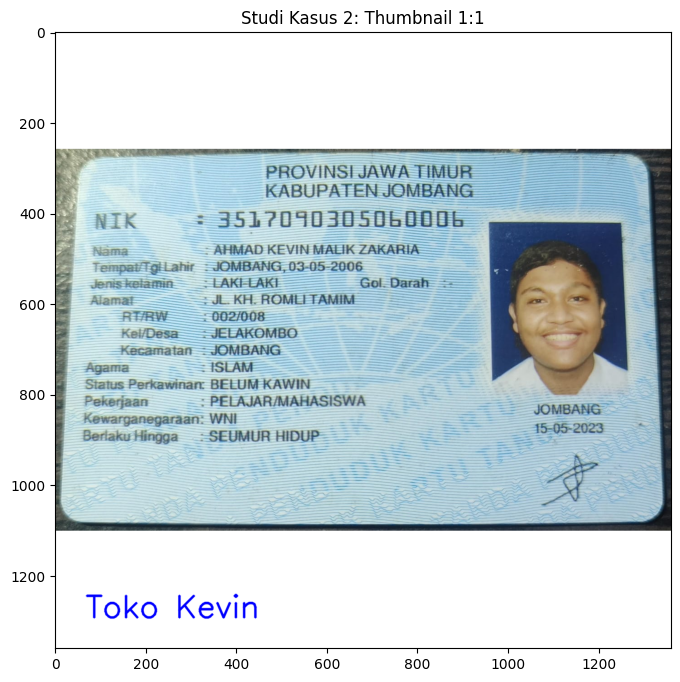

In [40]:
img_kasus2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w = img_kasus2.shape[:2]

sisi = max(h, w)

thumbnail = np.full((sisi, sisi, 3), 255, dtype=np.uint8)

y_offset = (sisi - h) // 2
x_offset = (sisi - w) // 2

thumbnail[y_offset:y_offset+h, x_offset:x_offset+w] = img_kasus2

font_scale_toko = sisi / 600
thickness_toko = max(1, int(font_scale_toko * 2))

cv.putText(thumbnail, 'Toko Kevin', (int(sisi * 0.05), int(sisi * 0.95)),
           cv.FONT_HERSHEY_SIMPLEX, font_scale_toko, (0, 0, 255), thickness_toko, cv.LINE_AA)

plt.figure(figsize=(8, 8))
plt.imshow(thumbnail)
plt.title("Studi Kasus 2: Thumbnail 1:1")
plt.show()